# Prediction du Risque de Diabete

Notebook: Analyse et classification du risque de diabete
Modele: Regression Logistique
Precision: 97%

## 1. Importations

In [1]:
# Bibliotheques de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Chargement des donnees

In [3]:
# Charger le fichier CSV
df = pd.read_csv('../data/diabetes_risk_dataset.csv')

## 3. Exploration des donnees

In [4]:
# Afficher les premieres lignes
df.head()

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


In [5]:
# Afficher les dernieres lignes
df.tail()

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
5995,5996,58,Male,21.8,158,89,6.3,5.3,198,132,High,1995,44.1,7.6,7,No,82.7,0.0,Low Risk
5996,5997,73,Male,47.3,193,109,33.7,6.1,250,209,Low,3401,61.4,5.3,10,Yes,150.0,100.0,High Risk
5997,5998,35,Male,31.0,139,90,15.1,5.3,190,164,Moderate,3022,86.7,6.8,3,Yes,102.7,22.3,Low Risk
5998,5999,58,Male,26.2,136,88,6.3,5.5,223,126,High,2311,28.2,8.4,5,No,90.6,3.9,Low Risk
5999,6000,54,Male,39.3,158,201,10.7,8.3,240,223,Low,2442,113.1,5.7,6,No,123.8,100.0,High Risk


In [6]:
# Dimensions du dataset
df.shape

(6000, 19)

In [7]:
# Noms des colonnes
df.columns

Index(['Patient_ID', 'age', 'gender', 'bmi', 'blood_pressure',
       'fasting_glucose_level', 'insulin_level', 'HbA1c_level',
       'cholesterol_level', 'triglycerides_level', 'physical_activity_level',
       'daily_calorie_intake', 'sugar_intake_grams_per_day', 'sleep_hours',
       'stress_level', 'family_history_diabetes', 'waist_circumference_cm',
       'diabetes_risk_score', 'diabetes_risk_category'],
      dtype='str')

In [8]:
# Types de donnees
df.dtypes

Patient_ID                      int64
age                             int64
gender                            str
bmi                           float64
blood_pressure                  int64
fasting_glucose_level           int64
insulin_level                 float64
HbA1c_level                   float64
cholesterol_level               int64
triglycerides_level             int64
physical_activity_level           str
daily_calorie_intake            int64
sugar_intake_grams_per_day    float64
sleep_hours                   float64
stress_level                    int64
family_history_diabetes           str
waist_circumference_cm        float64
diabetes_risk_score           float64
diabetes_risk_category            str
dtype: object

In [9]:
# Informations detaillees
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  6000 non-null   int64  
 1   age                         6000 non-null   int64  
 2   gender                      6000 non-null   str    
 3   bmi                         6000 non-null   float64
 4   blood_pressure              6000 non-null   int64  
 5   fasting_glucose_level       6000 non-null   int64  
 6   insulin_level               6000 non-null   float64
 7   HbA1c_level                 6000 non-null   float64
 8   cholesterol_level           6000 non-null   int64  
 9   triglycerides_level         6000 non-null   int64  
 10  physical_activity_level     6000 non-null   str    
 11  daily_calorie_intake        6000 non-null   int64  
 12  sugar_intake_grams_per_day  6000 non-null   float64
 13  sleep_hours                 6000 non-null   

In [10]:
# Verifier les valeurs nulles
df.isnull().sum()

Patient_ID                    0
age                           0
gender                        0
bmi                           0
blood_pressure                0
fasting_glucose_level         0
insulin_level                 0
HbA1c_level                   0
cholesterol_level             0
triglycerides_level           0
physical_activity_level       0
daily_calorie_intake          0
sugar_intake_grams_per_day    0
sleep_hours                   0
stress_level                  0
family_history_diabetes       0
waist_circumference_cm        0
diabetes_risk_score           0
diabetes_risk_category        0
dtype: int64

In [11]:
# Verifier les doublons
df.duplicated().sum()

np.int64(0)

In [12]:
# Resume statistique
df.describe()

,Patient_ID,age,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,waist_circumference_cm,diabetes_risk_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,52.230667,32.939667,144.482500,106.105500,15.080333,5.784583,217.490667,177.351500,2479.547000,66.555733,6.998700,5.086500,105.049600,48.691417
std,1732.195139,18.757508,7.510155,17.867248,31.213994,9.245581,0.956614,24.888595,51.897606,548.410642,39.576891,1.331378,2.342989,25.079335,37.242034
min,1.000000,20.000000,16.000000,91.000000,60.000000,2.000000,4.100000,139.000000,50.000000,1200.000000,0.000000,4.000000,1.000000,60.000000,0.000000
25%,1500.750000,36.000000,26.900000,132.000000,87.000000,7.100000,5.200000,200.000000,137.000000,2055.000000,35.100000,6.100000,3.000000,84.700000,12.900000
50%,3000.500000,53.000000,32.750000,144.000000,96.000000,13.800000,5.500000,217.000000,173.000000,2385.000000,58.300000,7.100000,5.000000,104.600000,43.900000
75%,4500.250000,68.000000,38.500000,157.000000,114.000000,21.000000,6.100000,234.000000,213.000000,2848.250000,89.300000,8.000000,7.000000,124.200000,88.800000
max,6000.000000,84.000000,50.000000,200.000000,281.000000,55.900000,11.000000,309.000000,383.000000,5249.000000,255.000000,10.000000,10.000000,150.000000,100.000000


## 4. Analyse Exploratoire des Donnees

In [14]:
# Fonction pour afficher les graphiques
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

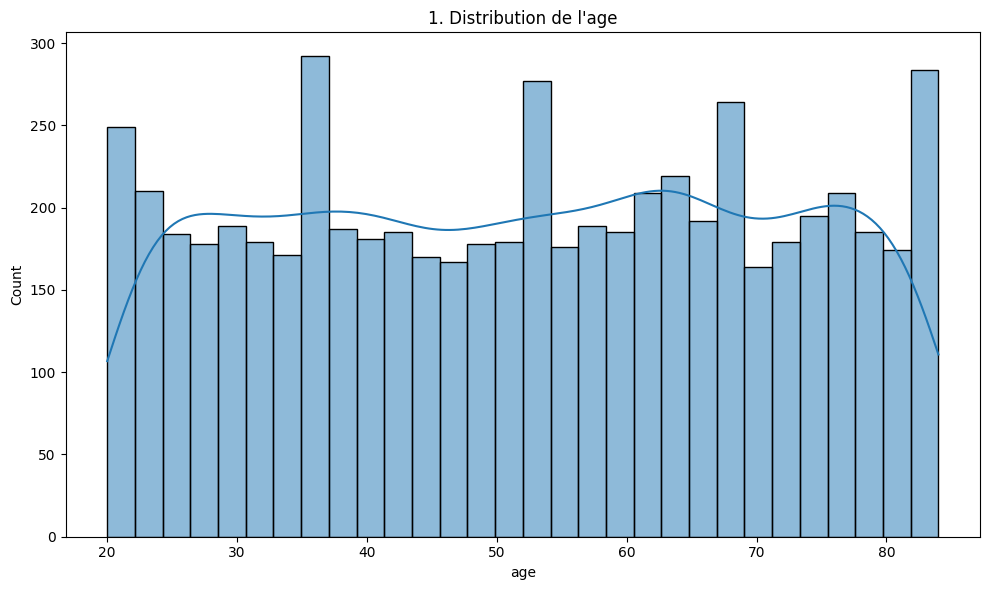

In [15]:
# Distribution de l'age
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True, bins=30)
plt.title(f'{plot_no}. Distribution de l\'age')
show_fig()
plot_no += 1

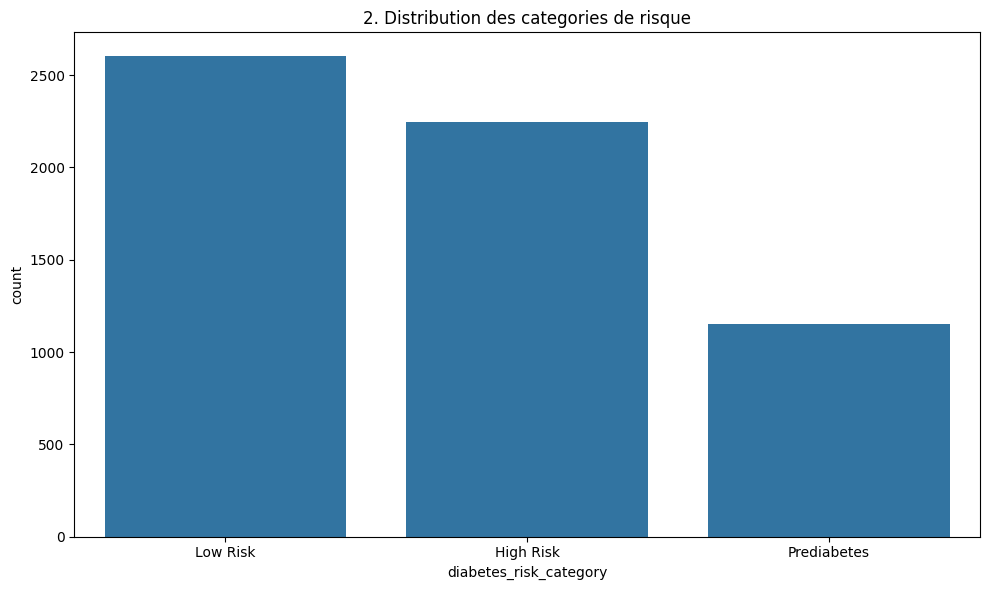

In [16]:
# Distribution des categories de risque
fig = plt.figure(figsize=(10,6))
sns.countplot(x='diabetes_risk_category', data=df, order=df['diabetes_risk_category'].value_counts().index)
plt.title(f'{plot_no}. Distribution des categories de risque')
show_fig()
plot_no += 1

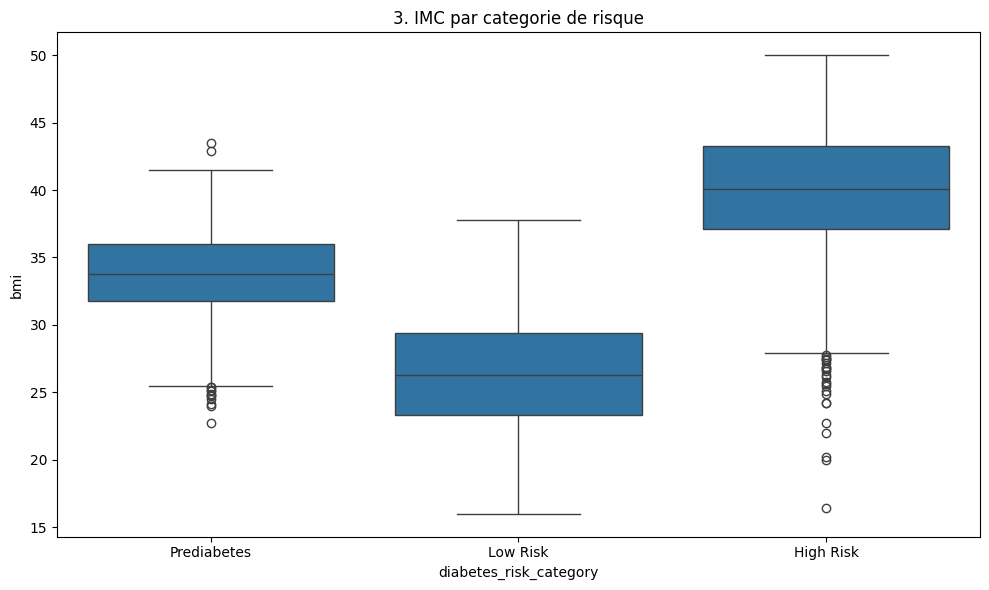

In [17]:
# IMC par categorie de risque
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes_risk_category', y='bmi', data=df)
plt.title(f'{plot_no}. IMC par categorie de risque')
show_fig()
plot_no += 1

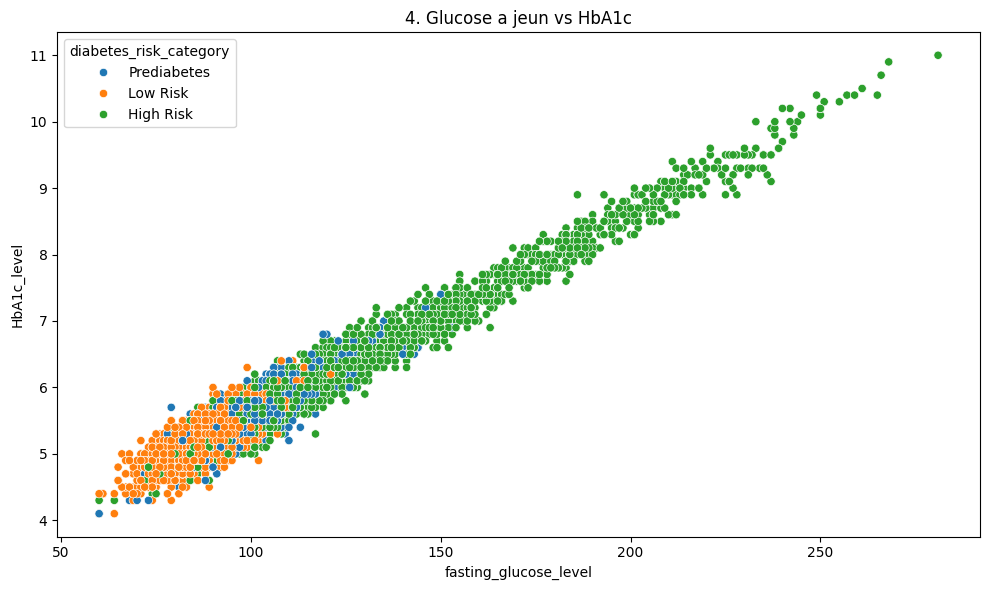

In [18]:
# Relation glucose et HbA1c
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='fasting_glucose_level', y='HbA1c_level', hue='diabetes_risk_category', data=df)
plt.title(f'{plot_no}. Glucose a jeun vs HbA1c')
show_fig()
plot_no += 1

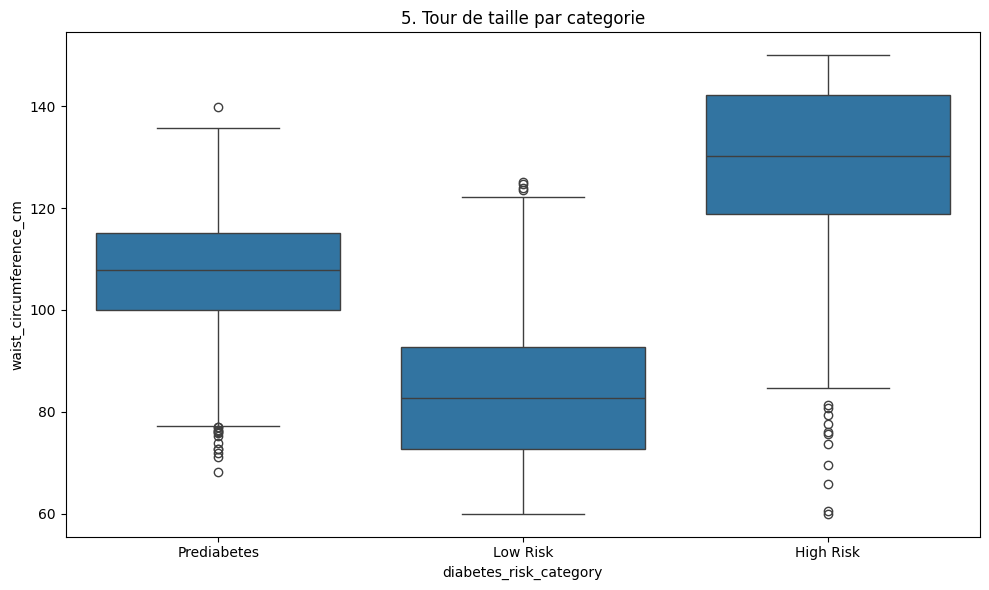

In [19]:
# Tour de taille par categorie
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes_risk_category', y='waist_circumference_cm', data=df)
plt.title(f'{plot_no}. Tour de taille par categorie')
show_fig()
plot_no += 1

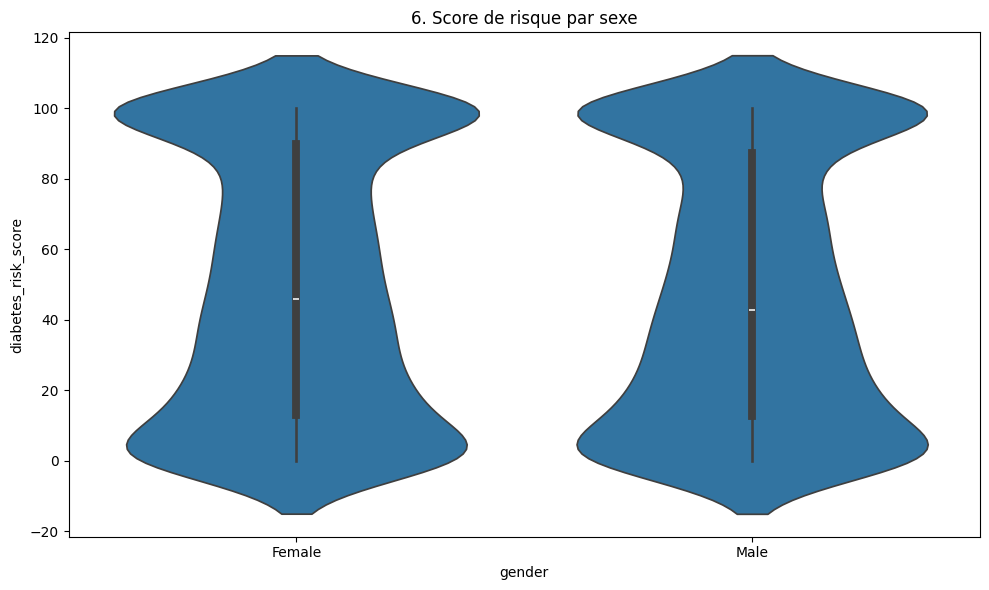

In [20]:
# Score de risque par sexe
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='gender', y='diabetes_risk_score', data=df)
plt.title(f'{plot_no}. Score de risque par sexe')
show_fig()
plot_no += 1

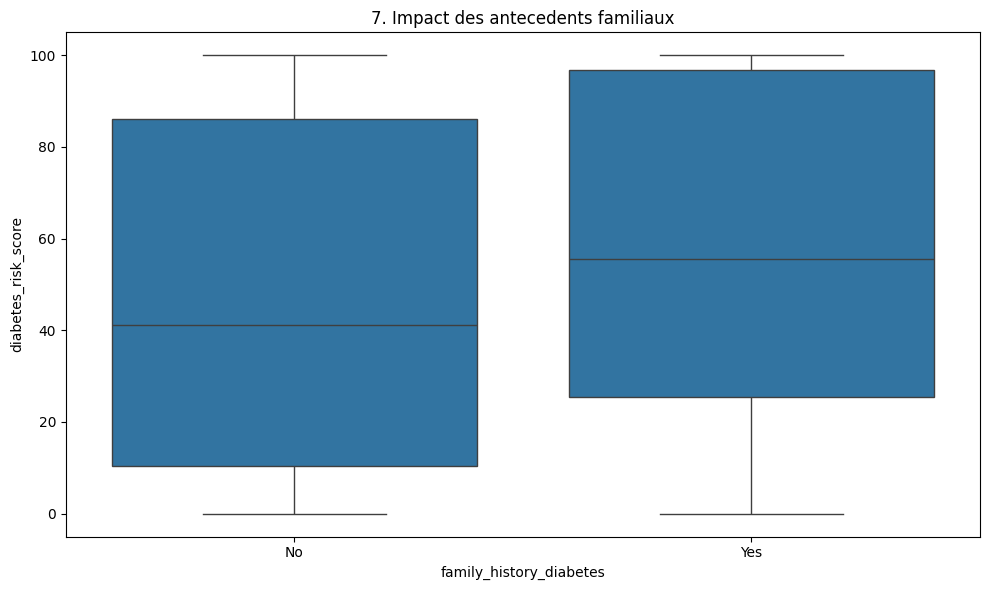

In [21]:
# Impact des antecedents familiaux
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='family_history_diabetes', y='diabetes_risk_score', data=df)
plt.title(f'{plot_no}. Impact des antecedents familiaux')
show_fig()
plot_no += 1

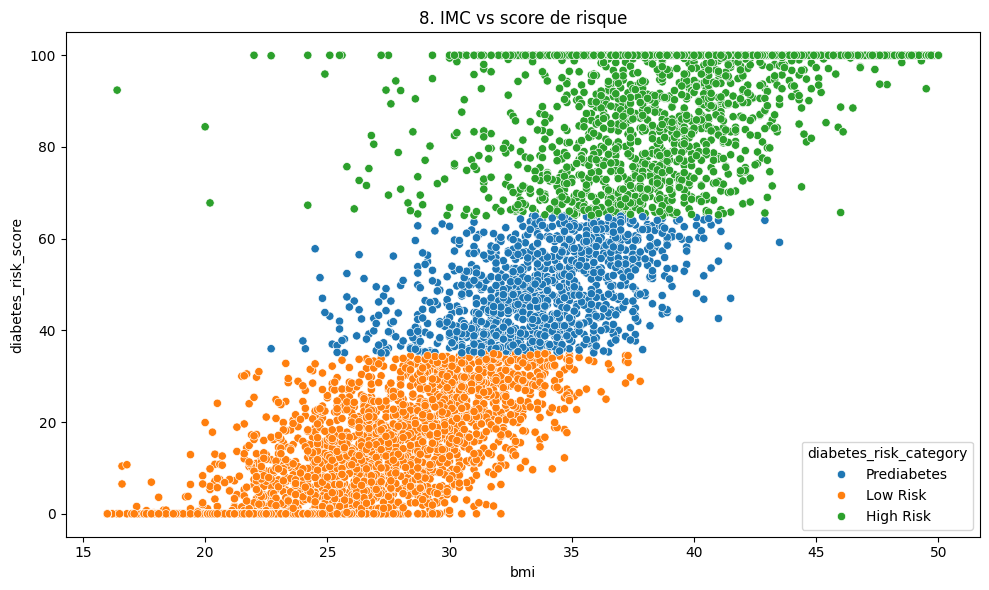

In [22]:
# IMC vs score de risque
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi', y='diabetes_risk_score', hue='diabetes_risk_category', data=df)
plt.title(f'{plot_no}. IMC vs score de risque')
show_fig()
plot_no += 1

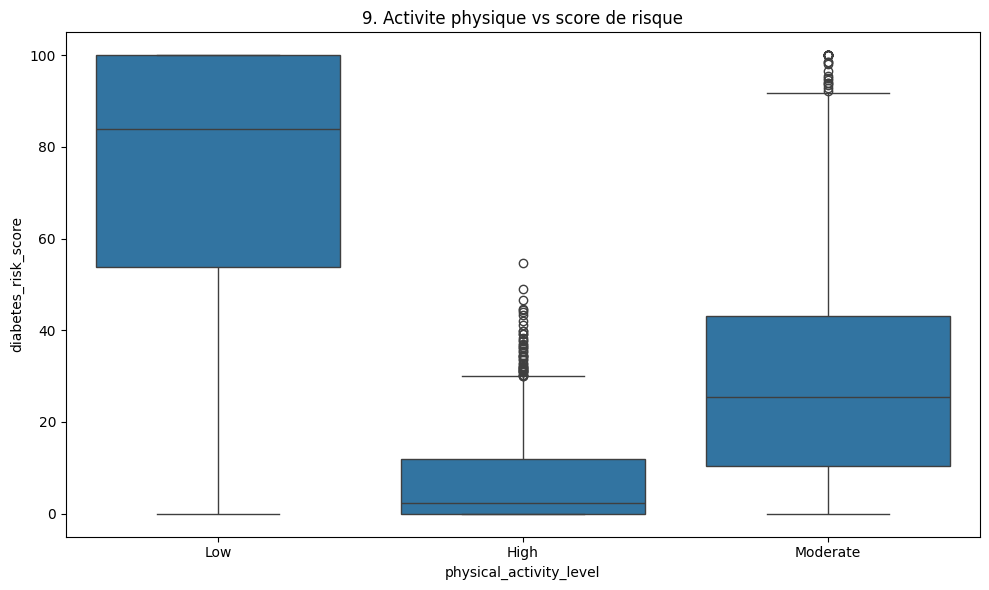

In [23]:
# Activite physique vs score
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='physical_activity_level', y='diabetes_risk_score', data=df)
plt.title(f'{plot_no}. Activite physique vs score de risque')
show_fig()
plot_no += 1

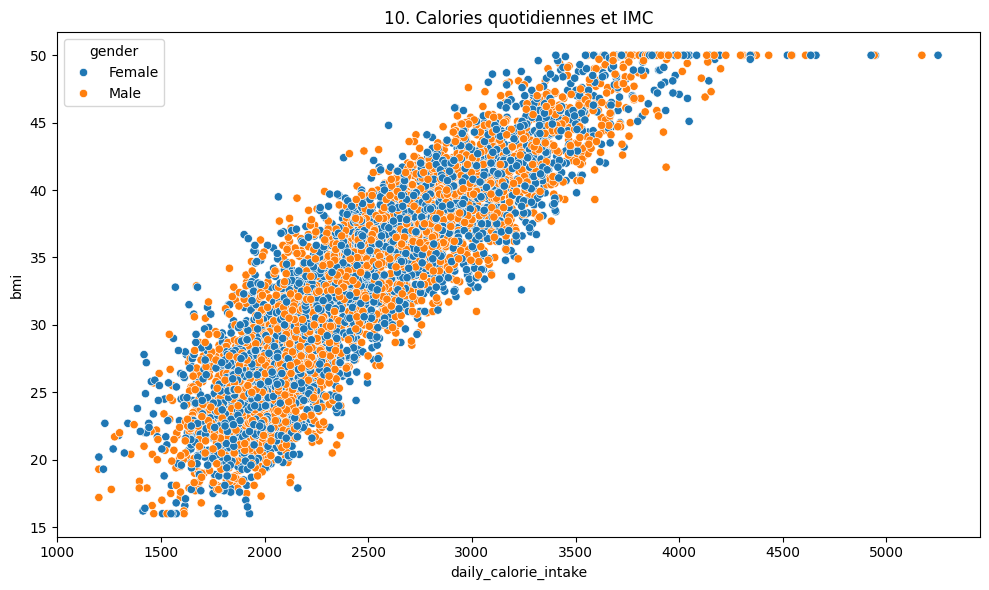

In [24]:
# Calories quotidiennes et IMC
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='daily_calorie_intake', y='bmi', hue='gender', data=df)
plt.title(f'{plot_no}. Calories quotidiennes et IMC')
show_fig()
plot_no += 1

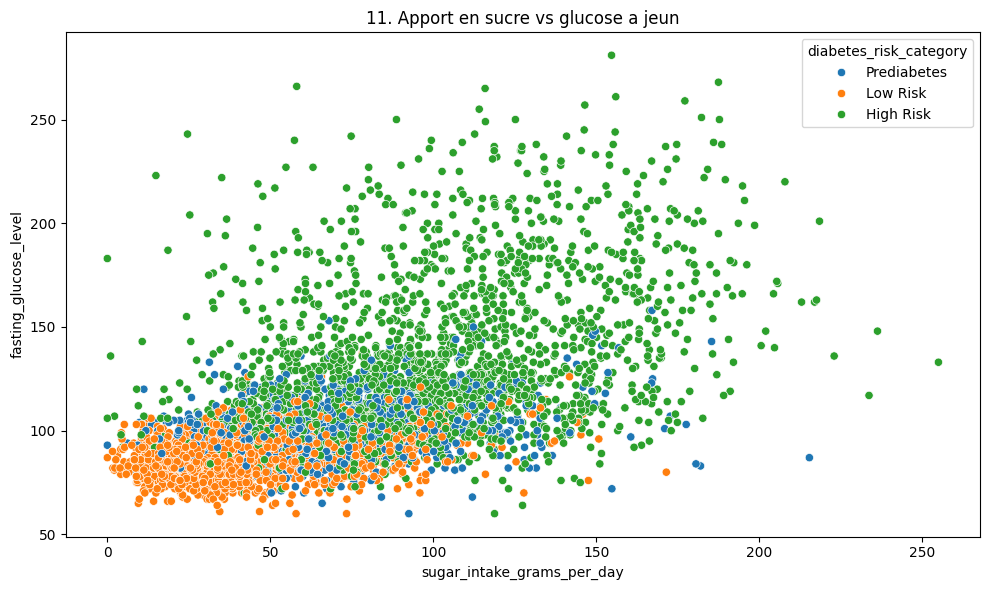

In [25]:
# Apport en sucre vs glucose
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='sugar_intake_grams_per_day', y='fasting_glucose_level', hue='diabetes_risk_category', data=df)
plt.title(f'{plot_no}. Apport en sucre vs glucose a jeun')
show_fig()
plot_no += 1

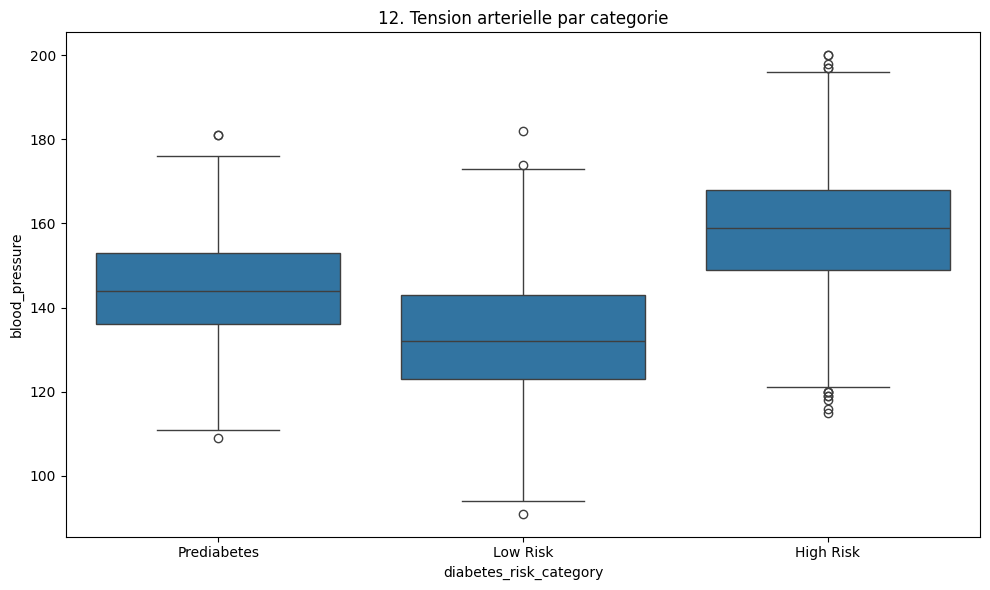

In [26]:
# Tension arterielle par categorie
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes_risk_category', y='blood_pressure', data=df)
plt.title(f'{plot_no}. Tension arterielle par categorie')
show_fig()
plot_no += 1

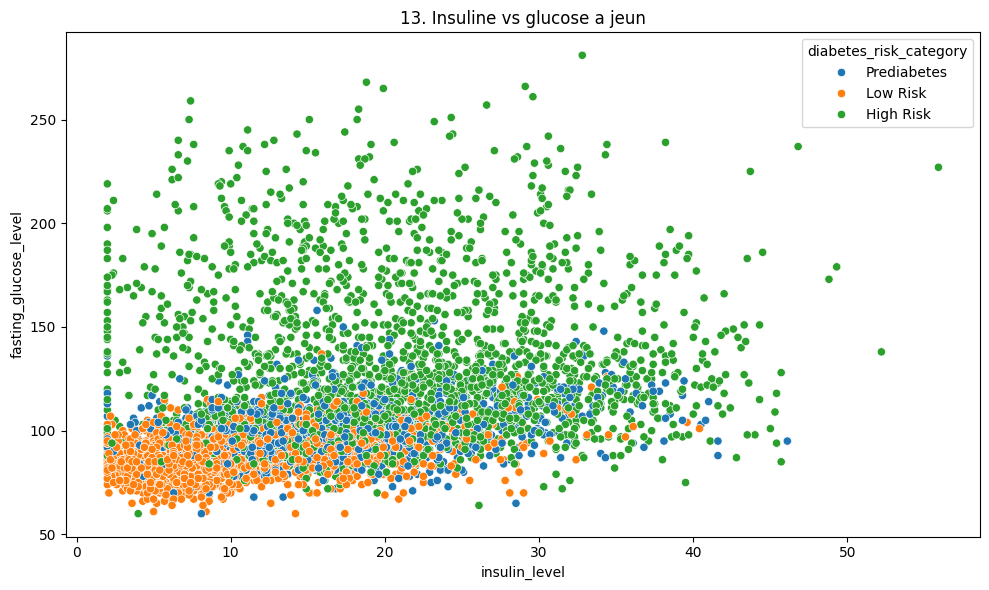

In [27]:
# Insuline vs glucose
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='insulin_level', y='fasting_glucose_level', hue='diabetes_risk_category', data=df)
plt.title(f'{plot_no}. Insuline vs glucose a jeun')
show_fig()
plot_no += 1

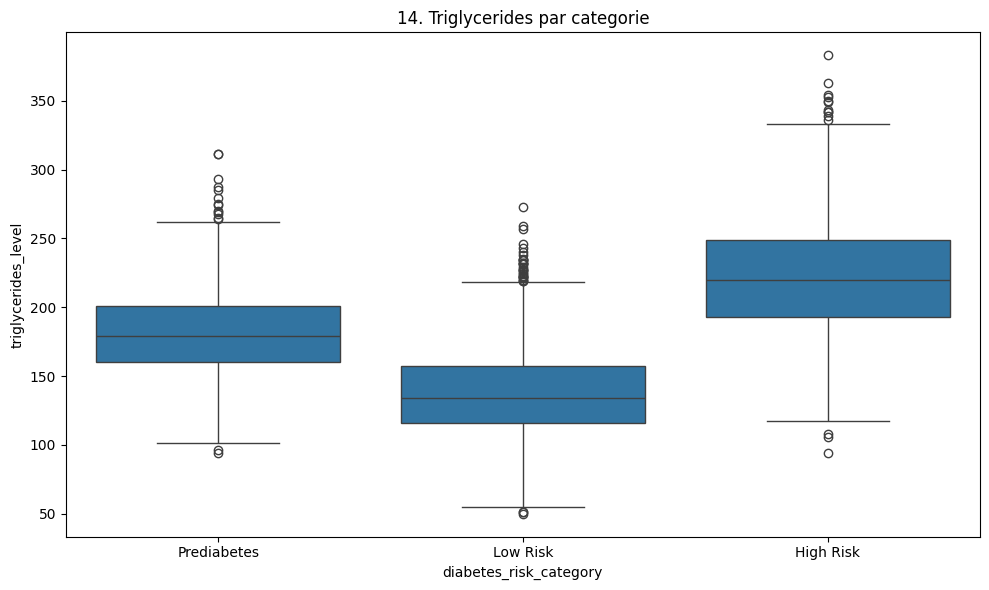

In [28]:
# Triglycerides par categorie
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes_risk_category', y='triglycerides_level', data=df)
plt.title(f'{plot_no}. Triglycerides par categorie')
show_fig()
plot_no += 1

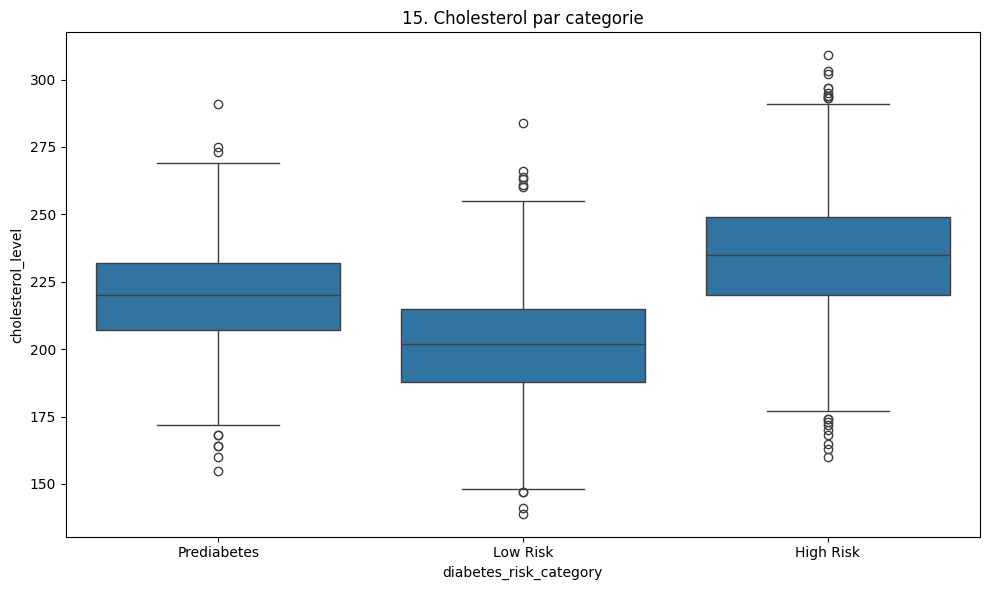

In [29]:
# Cholesterol par categorie
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes_risk_category', y='cholesterol_level', data=df)
plt.title(f'{plot_no}. Cholesterol par categorie')
show_fig()
plot_no += 1

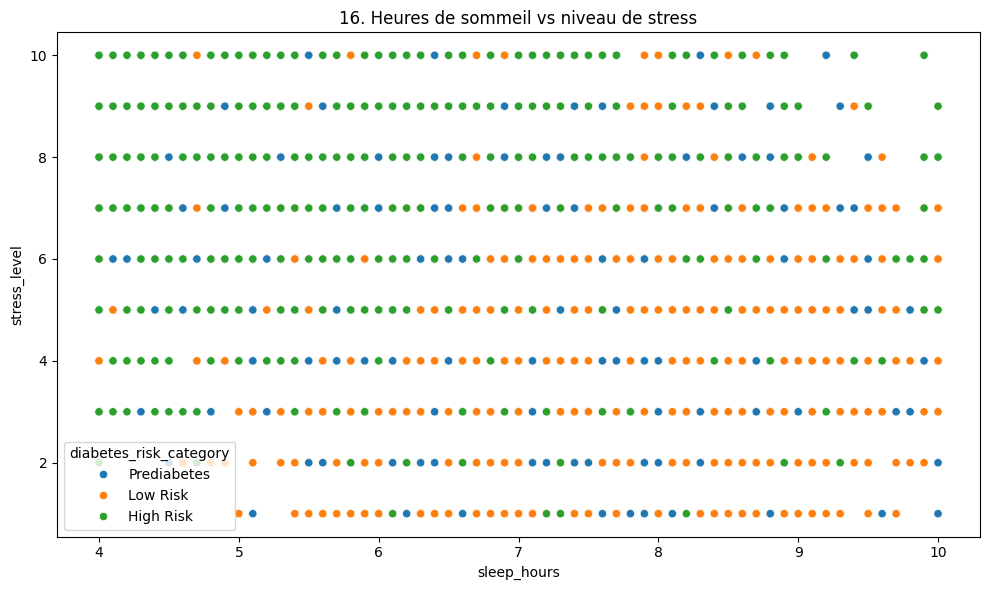

In [30]:
# Sommeil vs stress
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='sleep_hours', y='stress_level', hue='diabetes_risk_category', data=df)
plt.title(f'{plot_no}. Heures de sommeil vs niveau de stress')
show_fig()
plot_no += 1

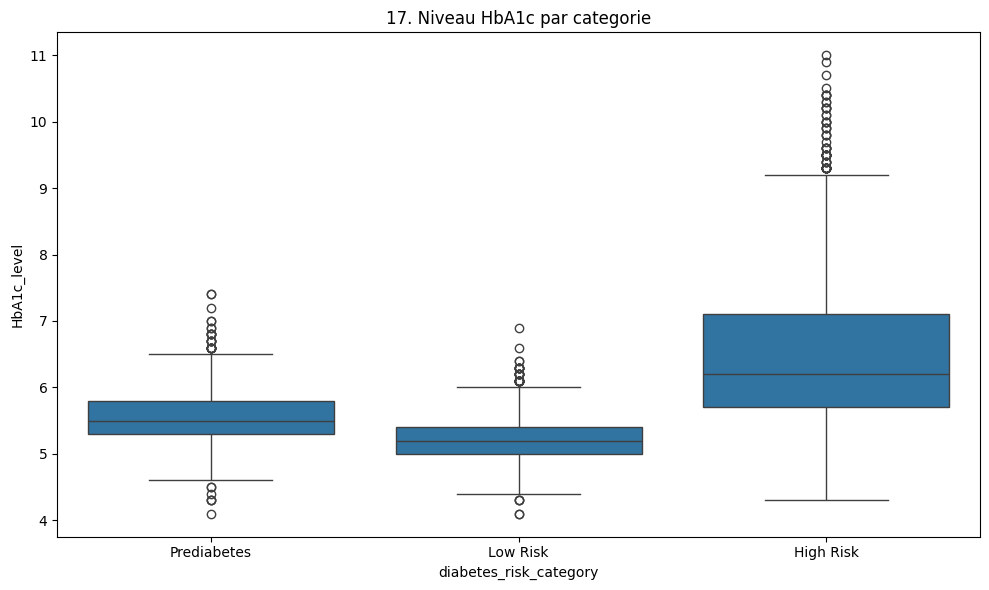

In [31]:
# HbA1c par categorie
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes_risk_category', y='HbA1c_level', data=df)
plt.title(f'{plot_no}. Niveau HbA1c par categorie')
show_fig()
plot_no += 1

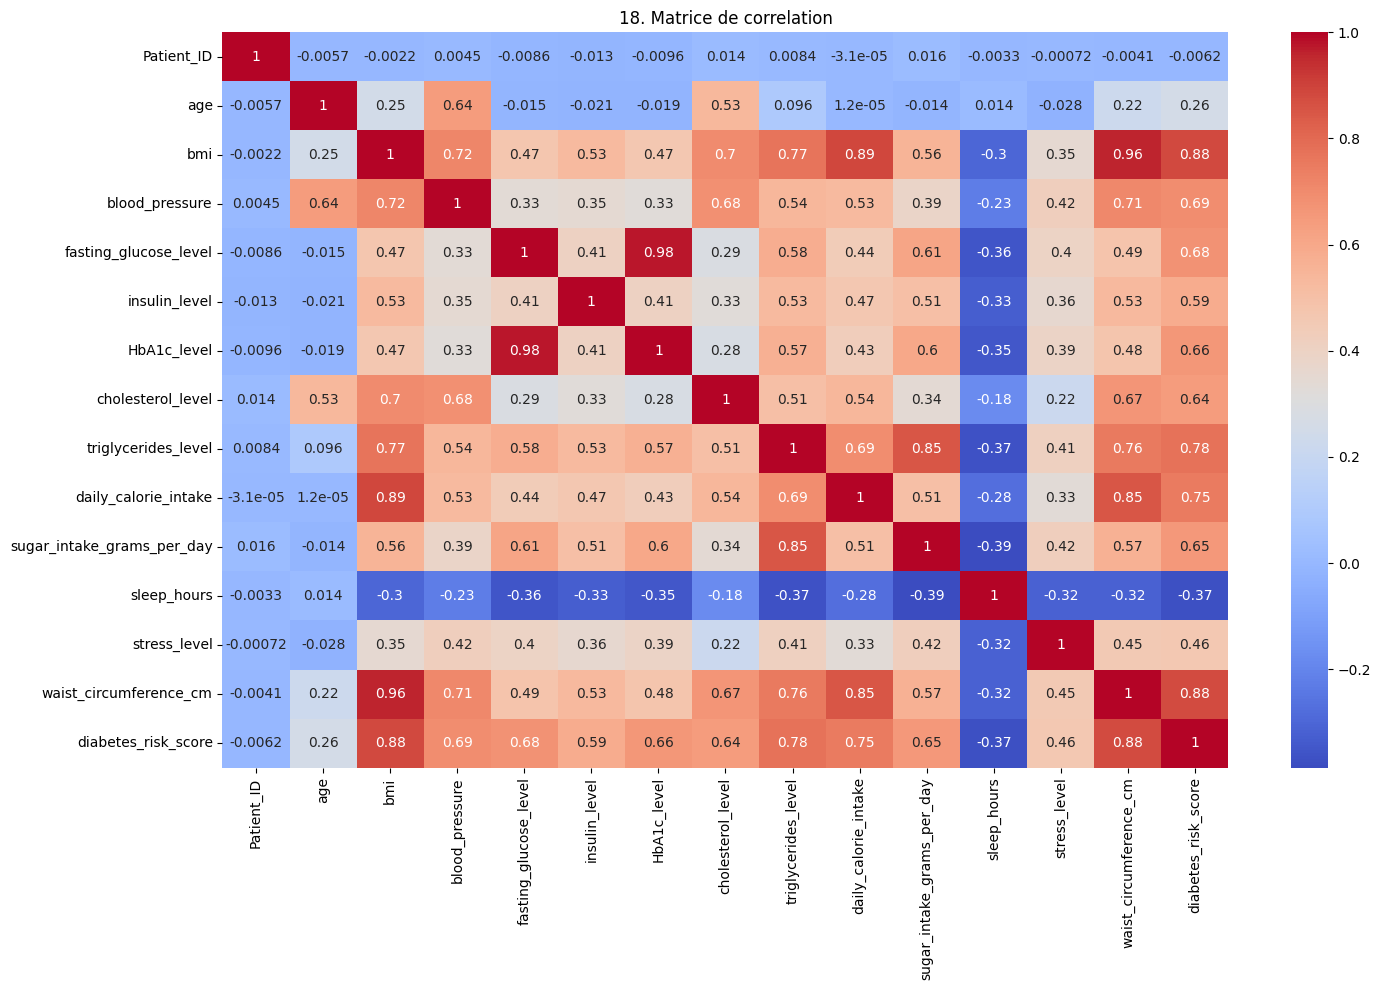

In [32]:
# Matrice de correlation
fig = plt.figure(figsize=(15, 10))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Matrice de correlation')
show_fig()
plot_no += 1

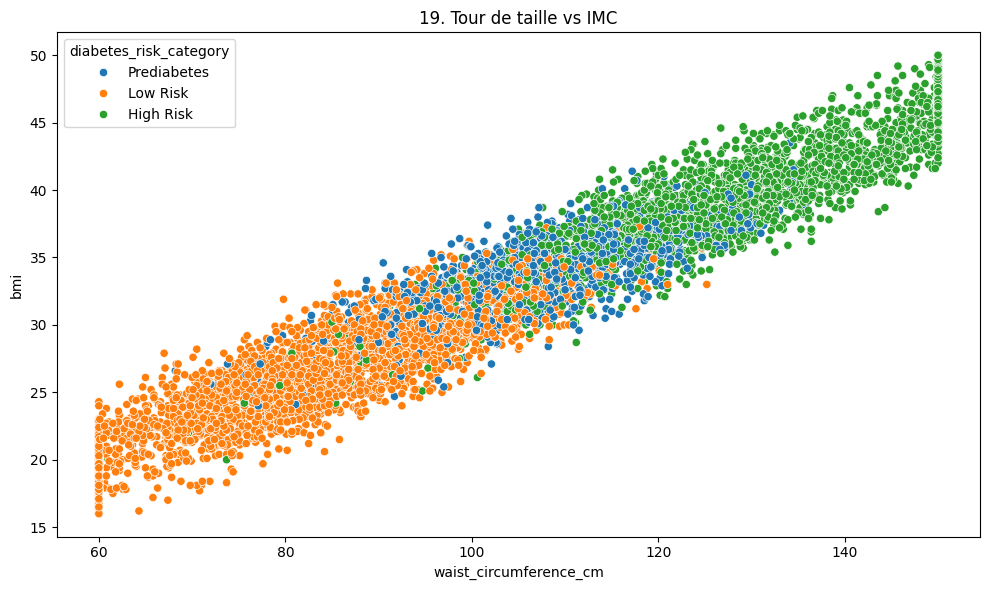

In [33]:
# Tour de taille vs IMC
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='waist_circumference_cm', y='bmi', hue='diabetes_risk_category', data=df)
plt.title(f'{plot_no}. Tour de taille vs IMC')
show_fig()
plot_no += 1

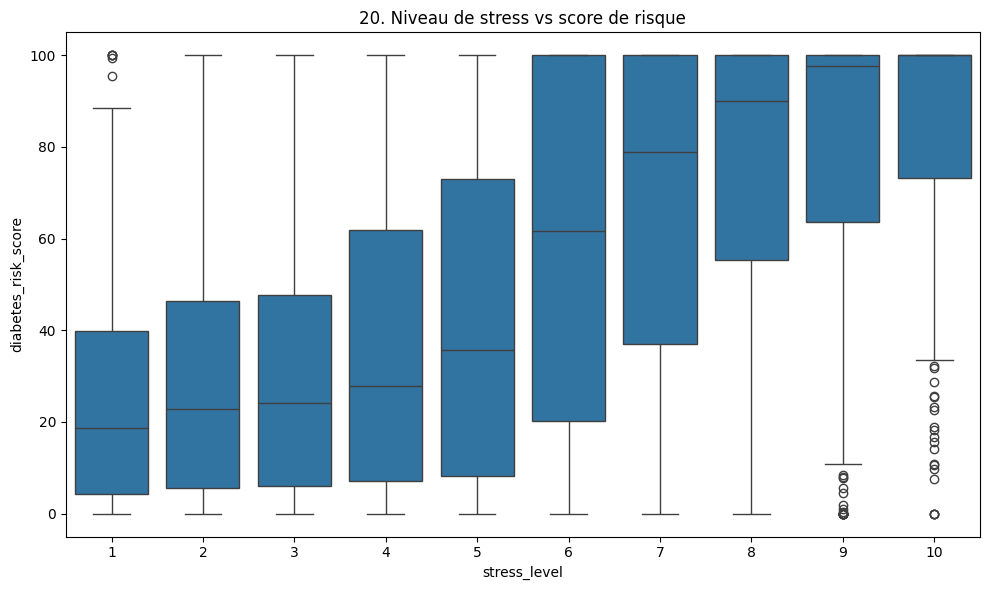

In [34]:
# Stress vs score de risque
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='stress_level', y='diabetes_risk_score', data=df)
plt.title(f'{plot_no}. Niveau de stress vs score de risque')
show_fig()
plot_no += 1

## 5. Preparation des donnees

In [35]:
# Separer les caracteristiques et la cible
X = df.drop(columns=['Patient_ID', 'diabetes_risk_score'])
y = df['diabetes_risk_score']

In [36]:
# Convertir en classification binaire
y = (y > y.median()).astype(int)

In [37]:
# Encoder les variables categiques
X = pd.get_dummies(X, drop_first=True)

In [38]:
# Division train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# Mise a l'echelle
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Entrainement du modele

In [40]:
# Initialiser et entrainer la regression logistique
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
# Faire des predictions
y_pred = model.predict(X_test)

## 7. Evaluation

In [42]:
# Calculer la precision
accuracy = accuracy_score(y_test, y_pred)
print("Precision du modele:", round(accuracy * 100, 2), "%")

Precision du modele: 97.17 %


In [43]:
# Rapport de classification
print("\nRapport de Classification:\n")
print(classification_report(y_test, y_pred))


Rapport de Classification:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       575
           1       0.97      0.97      0.97       625

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



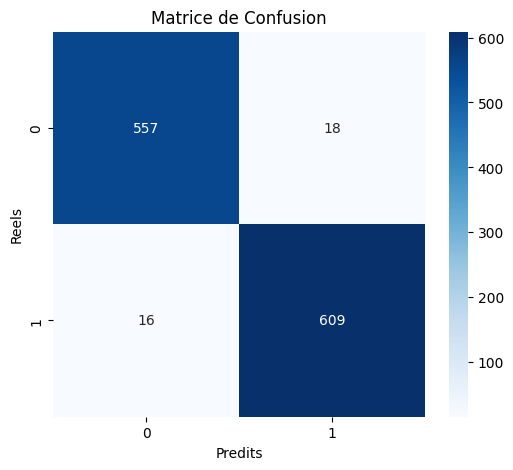

In [44]:
# Matrice de confusion
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de Confusion")
plt.xlabel("Predits")
plt.ylabel("Reels")
plt.show()